# JAWAD HASSAN
# 2230-0035
# BS AI
# ML
# LAB 03 
# LINEAR REGRESSION LAB TASK:

In [120]:
#import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [121]:
#load dataset
df = pd.read_csv('insurance_encoded - insurance_encoded.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,0,33.770,1,0,2,1725.55230
2,28,0,33.000,3,0,2,4449.46200
3,33,0,22.705,0,0,1,21984.47061
4,32,0,28.880,0,0,1,3866.85520


In [122]:
#understanding the data
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          sex  ...       region       charges
count  1338.000000  1338.000000  ...  1338.000000   1338.000000
mean     39.207025     0.494768  ...     1.515695  13270.422265
std      14.049960     0.500160  ...     1.104885  12110.011237
min      18.000000     0.000000  ...     0.000000   1121.873900
25%      27.000000     0.000000  ...     1.000

## UNIVARIATE LINEAR REGRESSION

In [123]:
#select variable:
#dep variable: charges
#indep variable:
# apply coorelation to find the best indep variable:
print(df.corr()['charges'].sort_values(ascending=False))
#also check for pca:
#for pca we need to scale so certain feature do not dominate the variance:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = df.drop('charges', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
#here variance is balanced after pca so there is no help from pcs here so we choose coorelation approach here and select age as indep variable
#because it has the highest coorelation with charges in continous numeric variable:
x=df[['age']]
y=df['charges']

charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
region     -0.006208
sex        -0.057292
Name: charges, dtype: float64
[0.20060309 0.1813664  0.16992314 0.16087702 0.15399424 0.1332361 ]


Text(0, 0.5, 'Charges ($)')

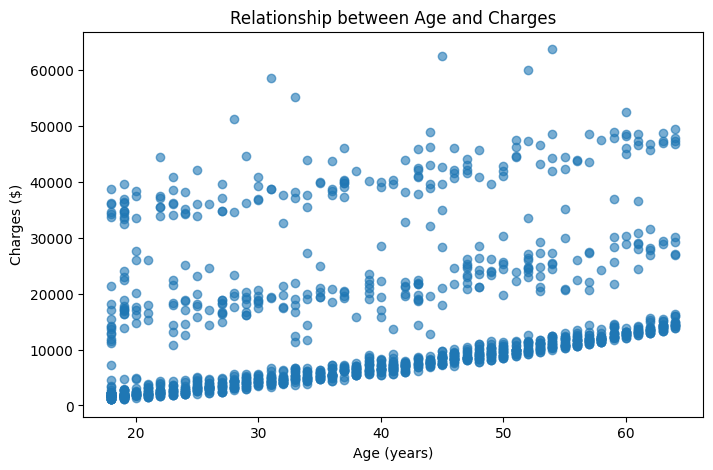

In [124]:
#visualization:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['charges'], alpha=0.6)
plt.title('Relationship between Age and Charges')
plt.xlabel('Age (years)')
plt.ylabel('Charges ($)')   
# visualization shows a positive relationship between age and charges, with charges increasing as age increases. 
# There is also some variability in charges for different ages, indicating that other factors like smokers may also influence the charges.
#Non-smokers → bottom band
#Some moderate-risk → middle
#Smokers → top band
#yes the relationship is not perfectly linear but it is still a strong positive, uptrend relationship, so we can proceed with linear regression.

In [125]:
#split the data into training 80 % and testing 20% sets:
xtrain, xtest,ytrain, ytest= train_test_split(x,y, test_size=0.2, random_state=42)
#this step is important to evaluate the model's performance on unseen data and to prevent overfitting.


In [126]:
#train the linear regression model:
model=LinearRegression()
model.fit(xtrain, ytrain)
print("Model trained successfully.")
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
#meaing coef: If age is 1 unit increase, charges increase by ≈ $240.

Model trained successfully.
Coefficient: [240.59655979]
Intercept: 3876.928684191691


In [127]:
#evaluation:
ypred=model.predict(xtest)
print("Mean Squared Error:", mean_squared_error(ytest, ypred))
print("R² Score:", r2_score(ytest, ypred))
#MSE is alot, and R² is 12% which is very low, meaning that the model is not a good fit for the data.
#This suggests that while there is a positive relationship between age and charges, age alone does not.

Mean Squared Error: 135983957.4805469
R² Score: 0.12408973539501944


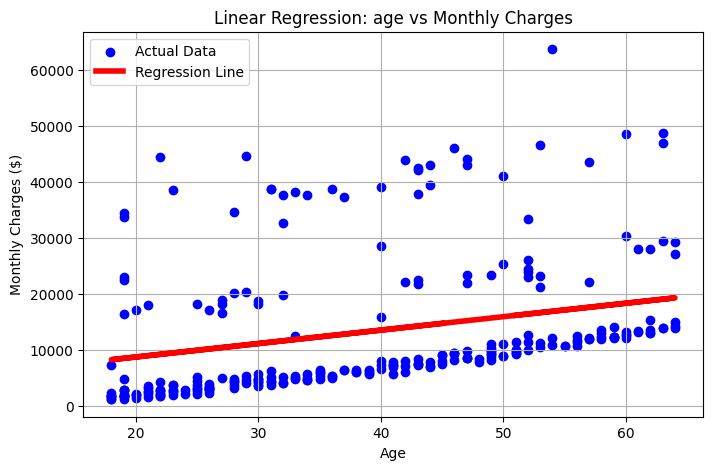

In [128]:
# Step 7: Plot the regression line against data points
plt.figure(figsize=(8, 5))
plt.scatter(xtest, ytest, color='blue', label='Actual Data')
plt.plot(xtest, ypred, color='red', linewidth=4, label='Regression Line')
plt.title('Linear Regression: age vs Monthly Charges')
plt.xlabel('Age')
plt.ylabel('Monthly Charges ($)')
plt.legend()
plt.grid(True)
plt.show()

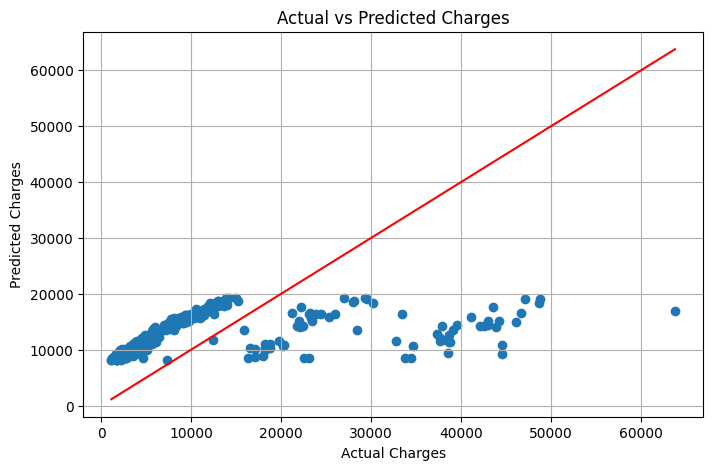

In [129]:
#actual vs predicted plot:
plt.figure(figsize=(8,5))
plt.scatter(ytest, ypred)

plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()],
         'r')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.grid(True)
plt.show()

## MULTIVARIATE LINEAR REGRESSION

In [130]:
#select all features as input variables:
x=df.drop('charges', axis=1)
y=df['charges']


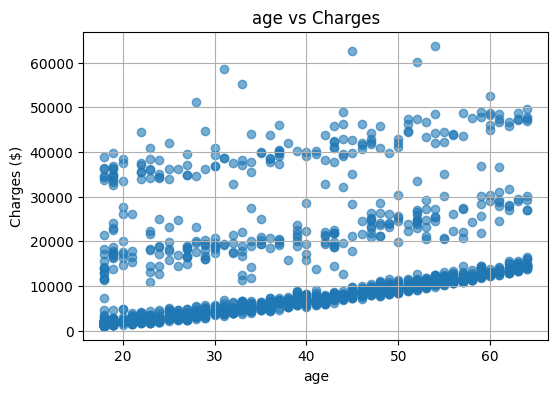

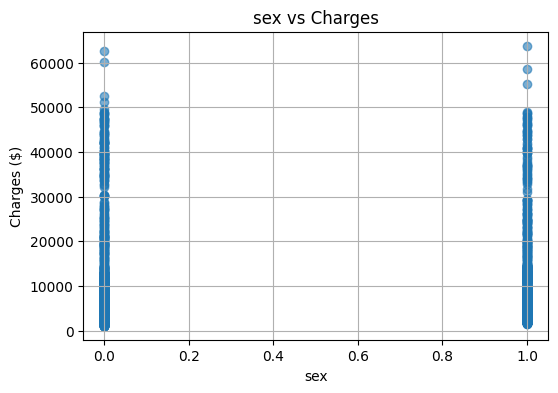

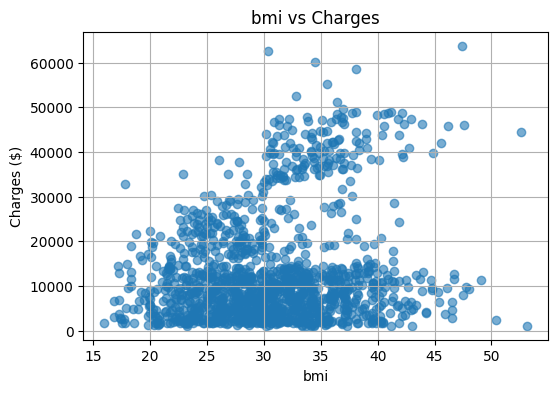

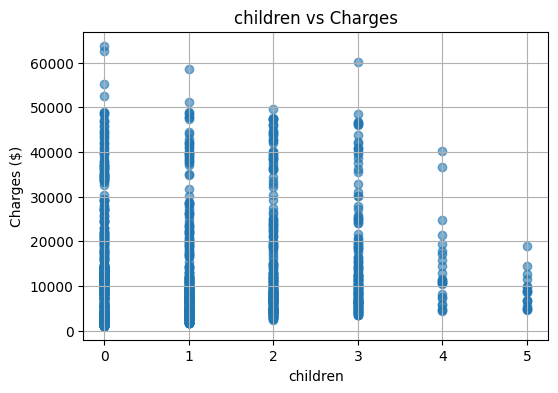

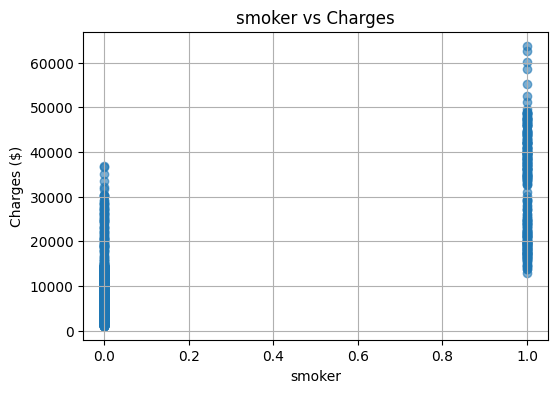

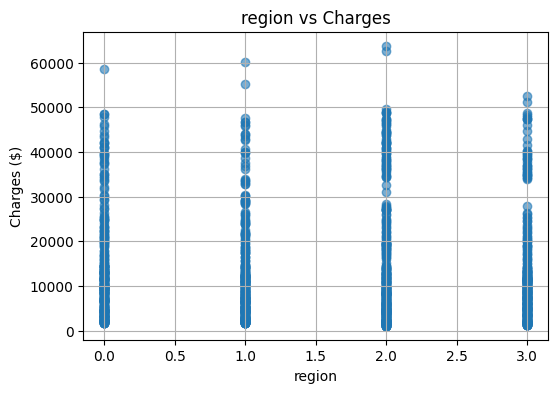

In [131]:
#scatterplot of all features vs charges:
for col in df.drop('charges', axis=1).columns:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df['charges'], alpha=0.6)
    plt.title(f'{col} vs Charges')
    plt.xlabel(col)
    plt.ylabel('Charges ($)')
    plt.grid(True)
    plt.show()

In [132]:
#train test split with all features:
xtrain, xtest,ytrain, ytest= train_test_split(x,y, test_size=0.2, random_state=42)
#train the model with all features:
model.fit(xtrain, ytrain)
#evaluate:
ypred=model.predict(xtest)
print("Mean Squared Error:", mean_squared_error(ytest, ypred))
print("R2 Score:", r2_score(ytest, ypred))

Mean Squared Error: 33635210.431178406
R2 Score: 0.7833463107364539


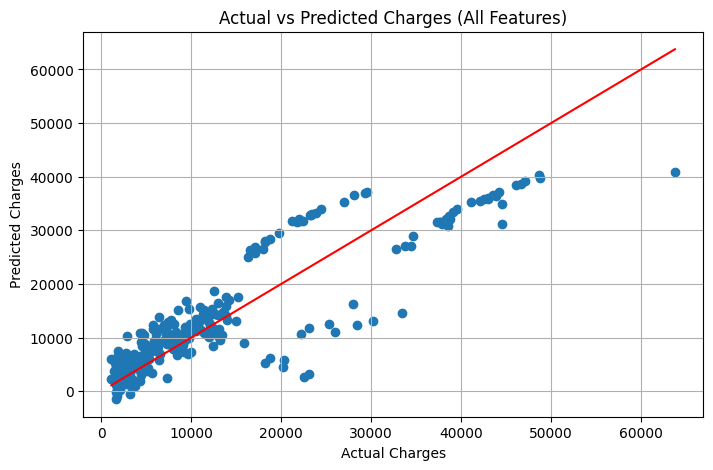

In [133]:
#plot actual vs predicted with all features:
plt.figure(figsize=(8,5))
plt.scatter(ytest, ypred)
plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()],
         'r')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges (All Features)")
plt.grid(True)

In [150]:
#prediction on new input values sample:
new_input = np.array([[40, 1, 27.9, 0, 1, 3]])
new_prediction = model.predict(new_input)
print(f"Predicted Charges: ${new_prediction[0]:.2f}")

Predicted Charges: $30537.91


/Users/macbook/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Comparison Result:
### univariate r square is 0.12 but multivariate r square is 0.78 hence multivariate model predicts better because it consist of all features and in graph we can see predicted line, its better on multivariate 

# Polynomial Regression


In [153]:
#trainning model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=3)
Xtrain_poly = poly.fit_transform(Xtrain)
Xtest_poly = poly.transform(Xtest)

model = LinearRegression()
model.fit(Xtrain_poly, ytrain)

ypred = model.predict(Xtest_poly)

In [154]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2796.7891374224146
MSE: 21485238.63292171
RMSE: 4635.2172152901
R2 Score: 0.8616076381013122


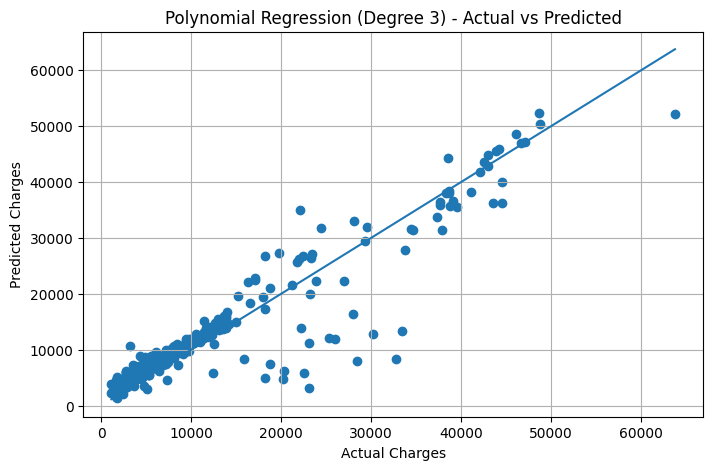

In [156]:
#plot graph:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(ytest, ypred)

plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()])

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Polynomial Regression (Degree 3) - Actual vs Predicted")
plt.grid(True)
plt.show()